In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

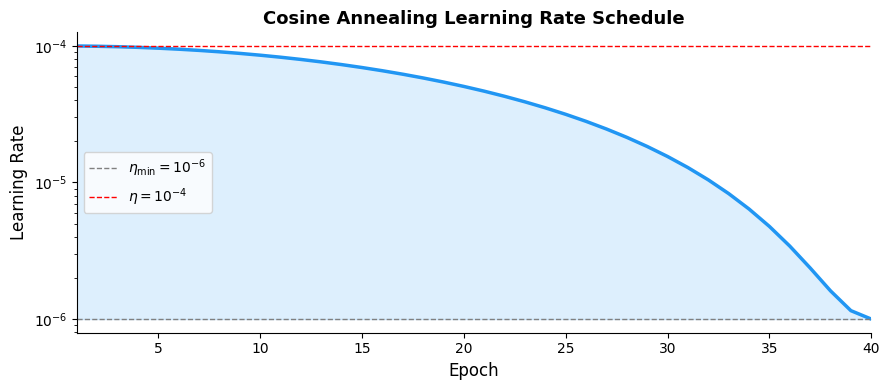

lr_schedule.png saved.


In [3]:
# ── 1. Learning Rate Schedule ─────────────────────────────────────────
T = 40
eta = 1e-4
eta_min = 1e-6
epochs = np.arange(1, T + 1)
lr = eta_min + 0.5 * (eta - eta_min) * (1 + np.cos(epochs * np.pi / T))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, lr, color='#2196F3', linewidth=2.5)
ax.fill_between(epochs, eta_min, lr, alpha=0.15, color='#2196F3')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Cosine Annealing Learning Rate Schedule',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(1, T)
ax.axhline(eta_min, color='gray', linestyle='--',
           linewidth=1, label=f'$\\eta_{{\\min}} = 10^{{-6}}$')
ax.axhline(eta, color='red', linestyle='--',
           linewidth=1, label=f'$\\eta = 10^{{-4}}$')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print('lr_schedule.png saved.')

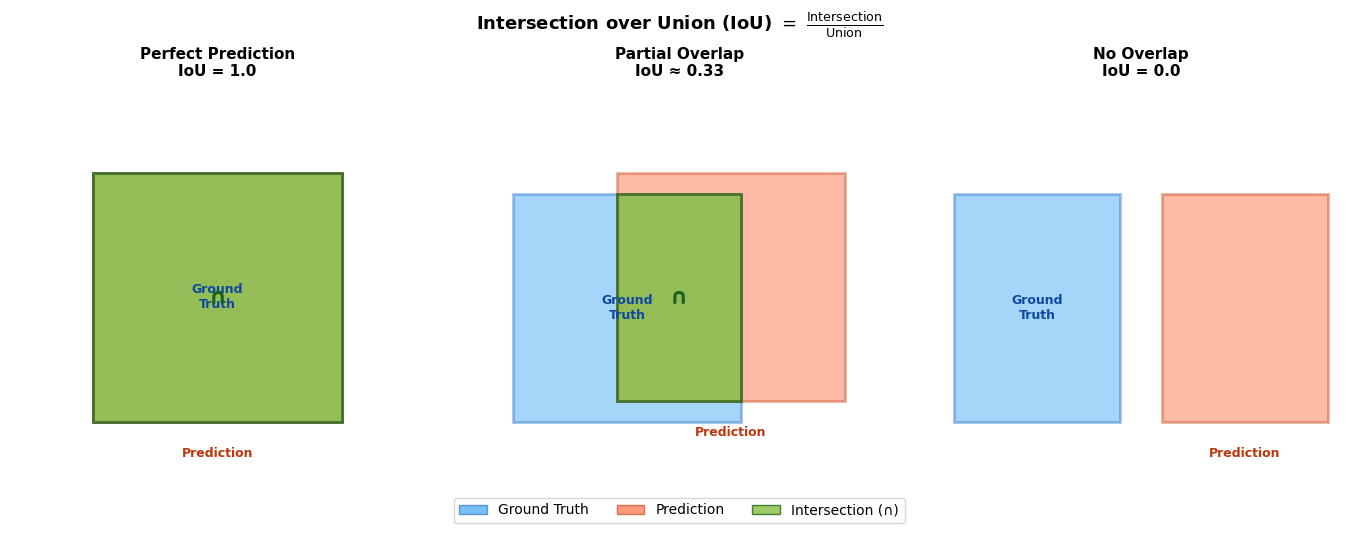

iou_diagram.png saved.


In [4]:
# ── 2. IoU Diagram ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = {
    'gt':           '#2196F3',   # blue  — ground truth only
    'pred':         '#FF5722',   # red   — prediction only
    'intersection': '#8BC34A',   # green — overlap
}


def draw_iou_panel(ax, title, gt_rect, pred_rect, show_labels=True):
    """Draw two overlapping rectangles and shade their regions."""
    from matplotlib.patches import Rectangle
    from matplotlib.patches import FancyArrowPatch

    gx, gy, gw, gh = gt_rect
    px, py, pw, ph = pred_rect

    # Intersection bounds
    ix = max(gx, px)
    iy = max(gy, py)
    ix2 = min(gx+gw, px+pw)
    iy2 = min(gy+gh, py+ph)
    has_inter = ix2 > ix and iy2 > iy

    # Ground truth (blue, semi-transparent)
    ax.add_patch(Rectangle((gx, gy), gw, gh,
                           facecolor=colors['gt'],
                           edgecolor='#1565C0',
                           alpha=0.4, linewidth=2,
                           label='Ground Truth'))
    # Prediction (red, semi-transparent)
    ax.add_patch(Rectangle((px, py), pw, ph,
                           facecolor=colors['pred'],
                           edgecolor='#BF360C',
                           alpha=0.4, linewidth=2,
                           label='Prediction'))
    # Intersection (green, opaque)
    if has_inter:
        ax.add_patch(Rectangle((ix, iy), ix2-ix, iy2-iy,
                               facecolor=colors['intersection'],
                               edgecolor='#33691E',
                               alpha=0.85, linewidth=2,
                               label='Intersection'))

    if show_labels:
        # Ground truth label
        ax.text(gx + gw/2, gy + gh/2, 'Ground\nTruth',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='#0D47A1')
        # Prediction label
        ax.text(px + pw/2, py - 0.06, 'Prediction',
                ha='center', va='top',
                fontsize=9, fontweight='bold', color='#BF360C')
        # Intersection label
        if has_inter:
            ax.text((ix+ix2)/2, (iy+iy2)/2, '∩',
                    ha='center', va='center',
                    fontsize=16, fontweight='bold', color='#1B5E20')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)


# Panel 1: Perfect prediction (IoU = 1.0)
draw_iou_panel(axes[0],
               'Perfect Prediction\nIoU = 1.0',
               gt_rect=(0.2, 0.2, 0.6, 0.6),
               pred_rect=(0.2, 0.2, 0.6, 0.6))

# Panel 2: Partial overlap (IoU ≈ 0.33)
draw_iou_panel(axes[1],
               'Partial Overlap\nIoU ≈ 0.33',
               gt_rect=(0.1, 0.2, 0.55, 0.55),
               pred_rect=(0.35, 0.25, 0.55, 0.55))

# Panel 3: No overlap (IoU = 0.0)
draw_iou_panel(axes[2],
               'No Overlap\nIoU = 0.0',
               gt_rect=(0.05, 0.2, 0.4, 0.55),
               pred_rect=(0.55, 0.2, 0.4, 0.55),
               show_labels=True)

# Shared legend
legend_handles = [
    mpatches.Patch(facecolor=colors['gt'],
                   edgecolor='#1565C0', alpha=0.6,
                   label='Ground Truth'),
    mpatches.Patch(facecolor=colors['pred'],
                   edgecolor='#BF360C', alpha=0.6,
                   label='Prediction'),
    mpatches.Patch(facecolor=colors['intersection'],
                   edgecolor='#33691E', alpha=0.85,
                   label='Intersection (∩)'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02),
           frameon=True)

fig.suptitle(
    r'Intersection over Union (IoU) $=$ '
    r'$\frac{\mathrm{Intersection}}{\mathrm{Union}}$',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('images/iou_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('iou_diagram.png saved.')

